In [33]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [34]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class_comparison"
less_bias_strength = "0.1"
method = "fw-mrs-temperature-svm"
data_set_name = "breast_cancer"

In [35]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_individual_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_individual_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

In [36]:
aurocs

,10.0,5.0,1.0,0.1,0.5,0.05,0.01,0.005,0.001,0.0,-0.001,-0.005,-0.05,-0.01,-0.5,-0.1,-1,-5.0,-10.0
0,0.983146,0.981875,0.982821,0.982289,0.981904,0.981224,0.970905,0.975813,0.976582,0.983885,0.968746,0.974690,0.985452,0.975015,0.982229,0.983057,0.982584,0.981579,0.983885
1,0.994234,0.991987,0.991662,0.987079,0.991750,0.987611,0.983323,0.987020,0.986487,0.991810,0.974423,0.972649,0.991425,0.988675,0.990893,0.989681,0.992135,0.993909,0.992253
2,0.985581,0.991113,0.981168,0.985876,0.992526,0.982786,0.968014,0.956744,0.963659,0.989201,0.977695,0.983669,0.980873,0.973752,0.983375,0.979932,0.991879,0.991202,0.988377


In [37]:
dropped_samples.keys()

Index(['10.0', '5.0', '1.0', '0.1', '0.5', '0.05', '0.01', '0.005', '0.001',
       '0.0', '-0.001', '-0.005', '-0.05', '-0.01', '-0.5', '-0.1', '-1',
       '-5.0', '-10.0'],
      dtype='object')

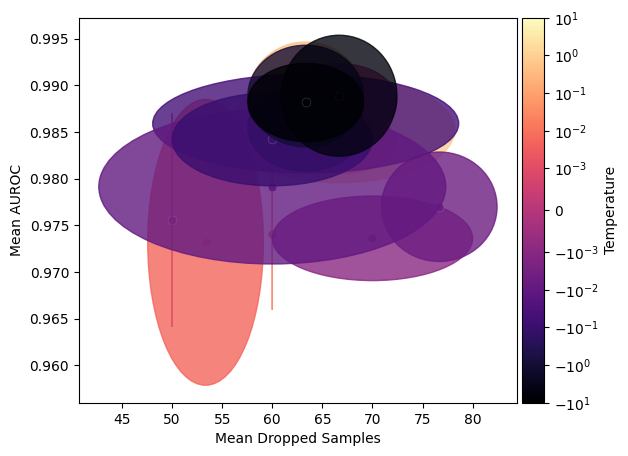

In [44]:
min_x = np.inf
min_y = np.inf
temperatures = dropped_samples.keys().values.astype(float)
cmap = sns.color_palette("magma", as_cmap=True)
norm = matplotlib.colors.SymLogNorm(linthresh=0.001, vmin=np.min(temperatures), vmax=np.max(temperatures))
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0

for key, dropped_value in dropped_samples.items():
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
    else: 
        marker = "o"
        
    color = cmap(norm(float(key)))
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=40, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.8,
                       color=color)
    ax.add_patch(ellipse)
    min_value = np.min(dropped_value.mean() - dropped_value.std())
    min_x =  min_value if min_value < min_x else min_x

    min_value = np.min(auroc_value.mean() - auroc_value.std())
    min_y =  min_value if min_value < min_y else min_y

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cb1 = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                norm=norm,
                                orientation='vertical')
cb1.set_label('Temperature')

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")